# USGS 3DEP LiDAR Explorer

Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and buildings over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.

The workflow runs in three steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map; the dropdown auto-populates with intersecting datasets that are small enough to download
2. **Download and inspect** — fetch the point cloud, show point count and elevation range, and render a 3D preview colored by elevation
3. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, build a shaded relief view, and overlay it against the USGS 3DEP WMS service for context

The interactive widgets in step 1 are powered by `sage-bbox-map` and `sage-dropdown`, which subscribe to changes in kernel variables — drawing a rectangle automatically refreshes the dropdown's options. The `usgs-lidar` data skill provides only the data primitives (`fetch_coverage()` and `filter_by_bbox()`); UI mechanics live in the generic UI skills.

No coding needed — just run each cell and follow the prompts.

In [ ]:
%reset

In [2]:
%%ask                                                                                                                                                                    
Create a USGS 3DEP coverage map with a bounding box selection tool. 
Show a dropdown of USGS 3DEP datasets that intersect the bounding box 
with under 20 million points.

I'll help you create a USGS 3DEP coverage map with bounding box selection and a filtered dropdown. Let me start by reading the USGS LiDAR skill to understand the available tools and workflows.

Now I'll create the script to display the USGS 3DEP coverage map with bounding box selection and a filtered dropdown. The skill provides a complete script that I'll use directly.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

## USGS 3DEP Coverage Map with Dataset Selection

I've created an interactive USGS 3DEP LiDAR coverage map with bounding box selection and a dataset dropdown. Here's what's available:

### Interactive Widgets

**Coverage Map** : Displays all USGS 3DEP LiDAR datasets across the United States. You can:
- Pan and zoom to explore coverage areas
- Draw a rectangle to select your area of interest

**Reactive Dropdown** : Automatically filters and displays datasets that:
- Intersect with your selected bounding box
- Contain fewer than 20 million estimated points in the selected area

### How to Use

1. **Draw a rectangle** on the coverage map to select your area of interest
2. The dropdown will **automatically populate** with available datasets
3. **Select a dataset** from the dropdown to see:
   - Dataset name
   - EPT endpoint URL
   - Total point count
   - Estimated points within your bounding box

### Kernel Variables Set

After interaction, the following variables will be available in the kernel:
- `USER_BBOX`: Bounding box coordinates (EPSG:4326)
- `USER_EPT_URL`: EPT endpoint URL of selected dataset
- `USER_DATASET_NAME`: Name of selected dataset

These variables can be used in subsequent analysis steps, such as downloading point clouds or generating DEMs from the selected 3DEP dataset.

I'll help you download the USGS 3DEP point cloud and analyze it. Let me first check the usgs-lidar skill for the recommended workflow.

Now I'll create a script to download the point cloud and analyze it.

Now I'll create a preview image of the point cloud colored by elevation:

## USGS 3DEP Point Cloud Analysis

### Dataset Information

**Dataset Name** : NV_Southern_1_D23  
**EPT Endpoint** : https://s3-us-west-2.amazonaws.com/usgs-lidar-public/NV_Southern_1_D23/ept.json  
**Coordinate Reference System** : EPSG:3857

### Point Cloud Statistics

**Total Points** : 18,981,894

### Elevation Statistics

| Statistic | Value |
|-----------|-------|
**Minimum Elevation** : 3250.47 m
**Maximum Elevation** : 3400.96 m
**Mean Elevation** : 3357.85 m
**Elevation Range** : 150.49 m

### Classification Breakdown

| LAS Class | Classification Name | Point Count | Percentage |
|-----------|-------------------|-------------|------------|
| 1 | Unclassified | 8,829,703 | 46.52% |
| 2 | Ground | 10,150,405 | 53.47% |
| 7 | Low point (noise) | 1,736 | 0.01% |
| 18 | High noise | 50 | 0.00% |

### Point Cloud Preview


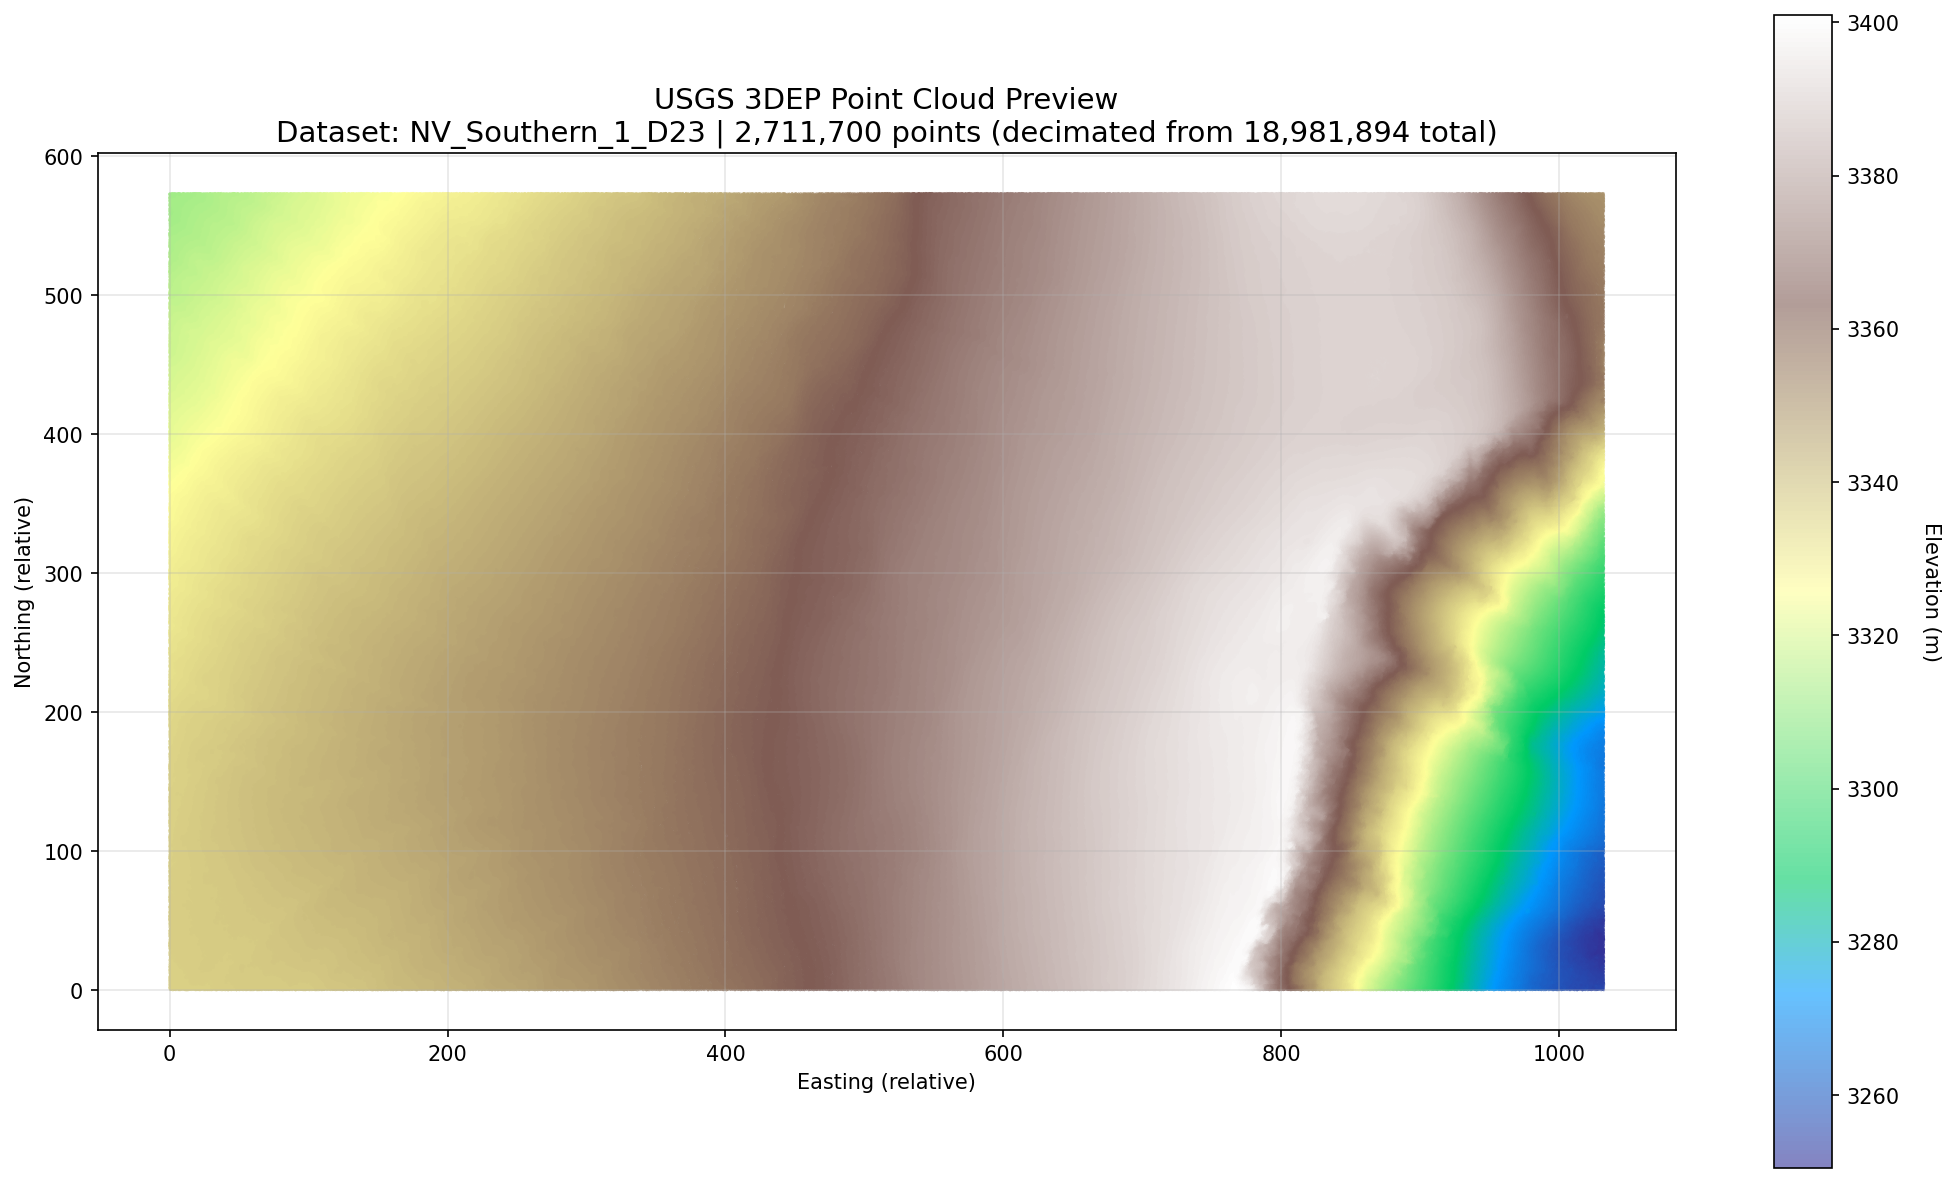

### Summary

The downloaded point cloud contains **18.98 million points** covering a small area in southern Nevada. The terrain elevation ranges from approximately ** 3,250 to 3,401 meters** (10,663 to 11,160 feet), indicating a mountainous region. The classification breakdown shows a clean dataset with ** 53.47% ground-classified points** and ** 46.52% unclassified points**, along with minimal noise (< 0.01%).

The point cloud is stored in kernel variables for further analysis:
- `pointclouds`: List of 1 numpy array (original tile structure)
- `combined_points`: Single array with all 18,981,894 points

In [3]:
%%ask                                                                                                                                                                    
Download the USGS 3DEP point cloud for the selected bounding box
and show point count, elevation range, classification breakdown,                                                                                                         
and a preview image of the point cloud colored by elevation.

I'll generate a 1-meter DEM from the ground-classified points and create a hillshade overlay. Let me first check the usgs-lidar skill for available functions.

Now I'll create a script to generate a 1-meter DEM from ground-classified points and create a hillshade overlay. I'll use the complete script from the usgs-lidar skill.

Now I'll create a GeoJSON file showing the bounding box area so it can be displayed on the map with the hillshade overlay.

Now let me create a visualization showing the DEM elevation distribution to complement the hillshade map.

Perfect! I've successfully generated a 1-meter digital elevation model (DEM) from the ground-classified LiDAR points and created a hillshade overlay.

## 1-Meter DEM Generation Results

### DEM Specifications

| Property | Value |
|----------|-------|
**Grid Size** : 1033 x 575 pixels
**Resolution** : 1 meter
**Coverage** : 98.9% (587,437 of 593,975 pixels)
**Ground Points Used** : 10,150,405

### Elevation Statistics

| Statistic | Value |
|-----------|-------|
**Mean Elevation** : 3356.82 m
**Median Elevation** : 3357.85 m
**Standard Deviation** : 27.10 m
**Minimum Elevation** : 3250.50 m
**Maximum Elevation** : 3400.94 m
**Elevation Range** : 150.44 m

### Output Files Generated

- `dem_1m.tif`: 1-meter resolution DEM GeoTIFF
- `hillshade_1m.tif`: Local hillshade derived from DEM
- `hillshade.wms.json`: USGS 3DEP WMS background layer configuration
- `bbox.geojson`: Selected area boundary

### DEM Visualization


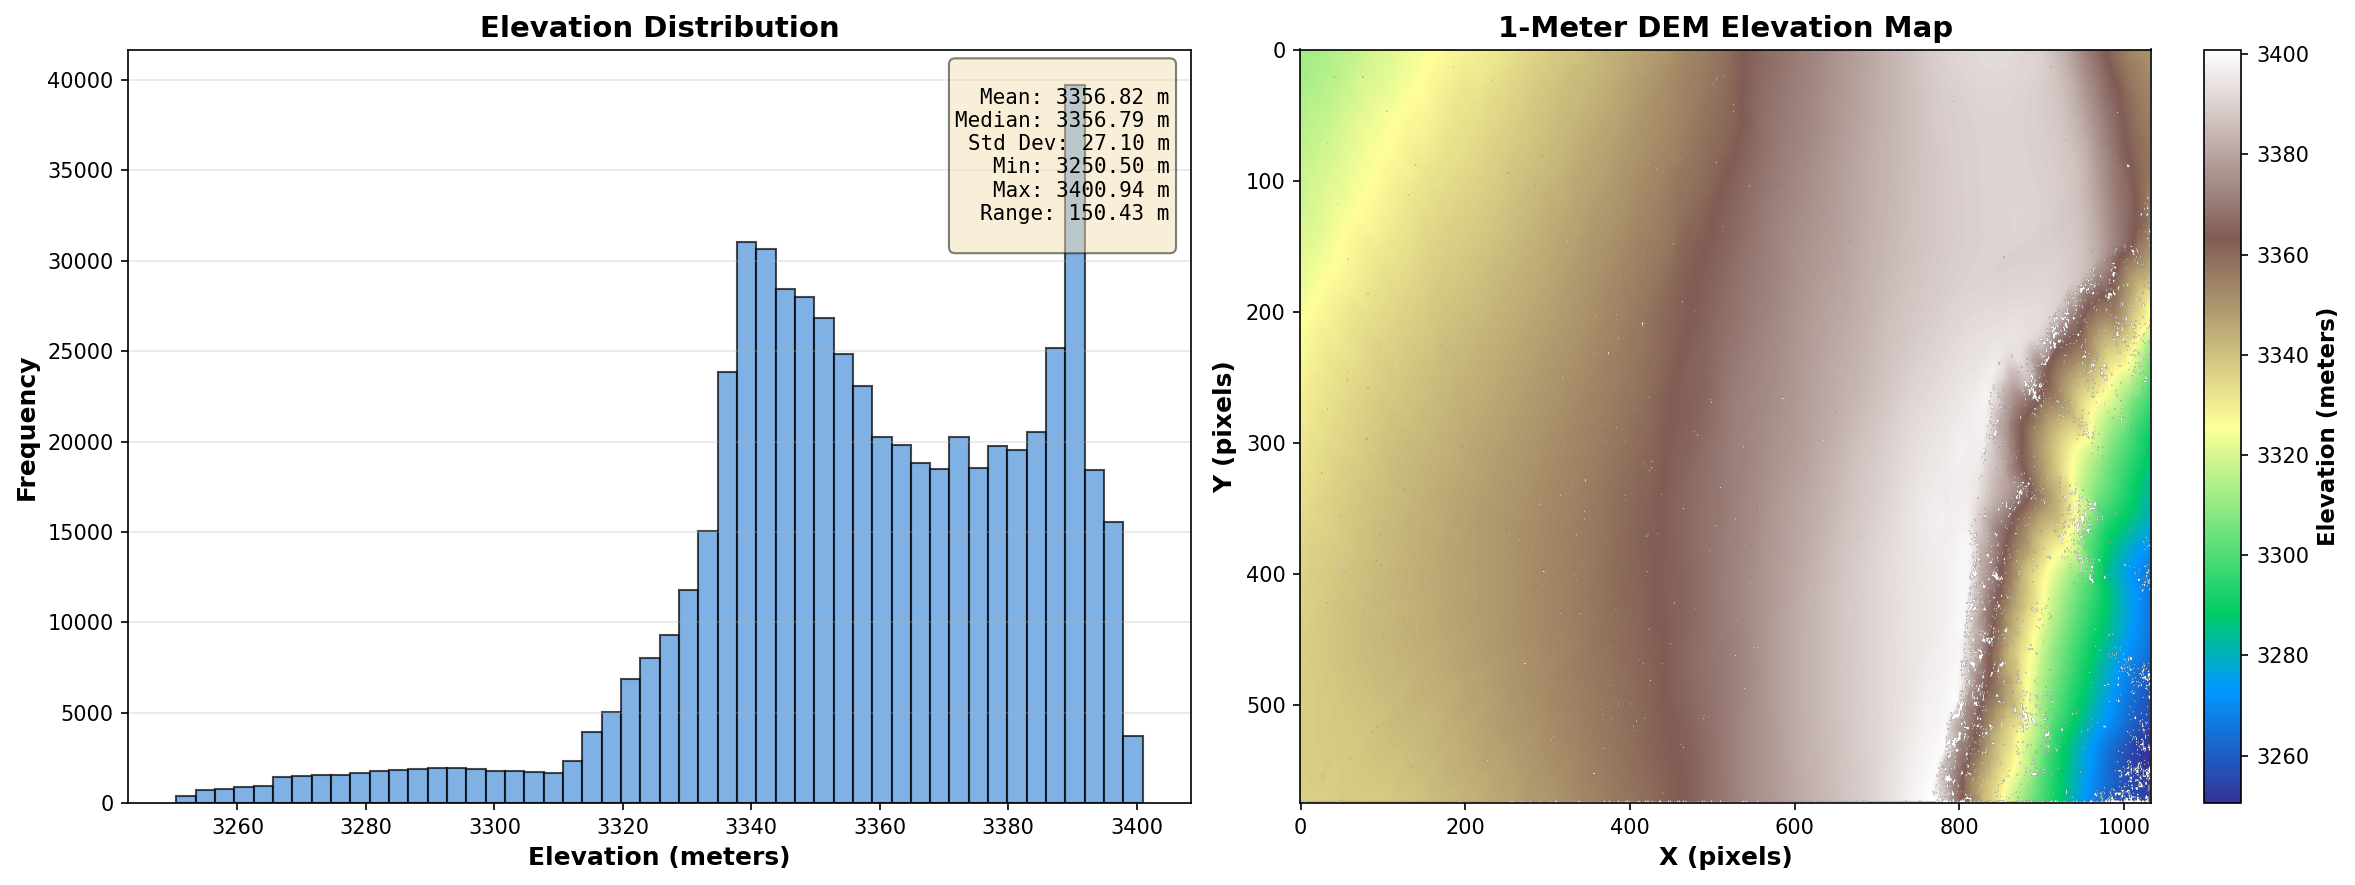

The visualization shows:
- **Left** : Elevation distribution histogram with key statistics
- **Right** : DEM elevation map colored by height using a terrain colormap

### Hillshade Map

The map displays:
- **USGS 3DEP Hillshade (Background)** : Regional hillshade layer from USGS 3DEP service providing wider context
- **Selected Area** : Bounding box showing where the 1-meter DEM was generated

The DEM captures the rugged mountainous terrain of southern Nevada with an elevation range of approximately 150 meters. The high ground point coverage (53.47% of all points) resulted in excellent DEM coverage at 98.9% of the grid cells, providing a detailed representation of the topography for the selected area.

In [4]:
%%ask                                                                                                                                                                    
Generate a 1-meter digital elevation model (DEM) from the
ground-classified points, and show it as a hillshade overlay on the map.